Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 213, 128, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 213, 128, 32) 896         input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 213, 128, 32) 128         conv2d[0][0]                     
__________________________________________________________________________________________________
inception_block (InceptionModul (None, 213, 128, 96) 19584       batch_normalization[0][0]        
______________________________________________________________________________________________

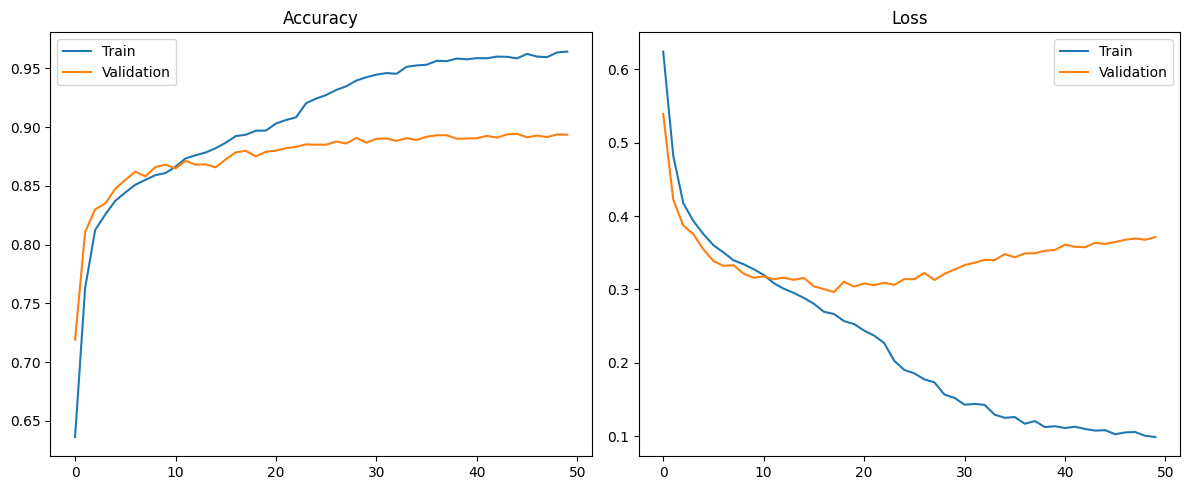


Classification Report:
              precision    recall  f1-score   support

non-defected       0.87      0.93      0.90      2000
    defected       0.92      0.86      0.89      2000

    accuracy                           0.89      4000
   macro avg       0.90      0.89      0.89      4000
weighted avg       0.90      0.89      0.89      4000



In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

ORIGINAL_HEIGHT = 24
ORIGINAL_WIDTH = 40
TARGET_WIDTH = 128
TARGET_HEIGHT = int(ORIGINAL_WIDTH * (TARGET_WIDTH / ORIGINAL_HEIGHT))
BATCH_SIZE = 32
NUM_CLASSES = 2
EPOCHS = 50
SEED = 42

DATASET_DIR = r"E:\CDUT\English\7 Term\Project\model\archive\panel_cell"

# Inception
class InceptionModule(layers.Layer):
    def __init__(self, filters, name="inception_block", **kwargs):
        super().__init__(name=name, **kwargs)
        self.filters = filters
        self.branch1 = models.Sequential([
            layers.Conv2D(filters[0], (1, 1), padding='same', activation='relu')
        ])
        self.branch2 = models.Sequential([
            layers.Conv2D(filters[1], (1, 1), padding='same', activation='relu'),
            layers.Conv2D(filters[2], (3, 3), padding='same', activation='relu')
        ])
        self.branch3 = models.Sequential([
            layers.Conv2D(filters[3], (1, 1), padding='same', activation='relu'),
            layers.Conv2D(filters[4], (5, 5), padding='same', activation='relu')
        ])
        self.branch4 = models.Sequential([
            layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same'),
            layers.Conv2D(filters[5], (1, 1), padding='same', activation='relu')
        ])
    def call(self, inputs):
        return layers.concatenate([
            self.branch1(inputs),
            self.branch2(inputs),
            self.branch3(inputs),
            self.branch4(inputs)
        ], axis=-1)
    def get_config(self):
        config = super().get_config()
        config.update({'filters': self.filters})
        return config

class MultiHeadAttention(layers.Layer):
    def __init__(self, num_heads, key_dim, name="multihead_attn", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.Wq = layers.Dense(key_dim * num_heads)
        self.Wk = layers.Dense(key_dim * num_heads)
        self.Wv = layers.Dense(key_dim * num_heads)
        self.dense = layers.Dense(key_dim * num_heads)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        Q = tf.reshape(self.Wq(inputs), [batch_size, -1, self.num_heads, self.key_dim])
        K = tf.reshape(self.Wk(inputs), [batch_size, -1, self.num_heads, self.key_dim])
        V = tf.reshape(self.Wv(inputs), [batch_size, -1, self.num_heads, self.key_dim])
        attention = tf.einsum('bqhd,bkhd->bhqk', Q, K) / tf.sqrt(tf.cast(self.key_dim, tf.float32))
        attention = tf.nn.softmax(attention, axis=-1)
        output = tf.einsum('bhqk,bkhd->bqhd', attention, V)
        output = tf.reshape(output, [batch_size, -1, self.num_heads * self.key_dim])
        return self.dense(output), attention

    def get_config(self):
        return {'num_heads': self.num_heads, 'key_dim': self.key_dim}

def build_model():
    inputs = layers.Input(shape=(TARGET_HEIGHT, TARGET_WIDTH, 3))
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = InceptionModule([16, 16, 32, 16, 32, 16])(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Reshape((64, 106 * 96))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    attn_output, _ = MultiHeadAttention(num_heads=4, key_dim=32)(x)
    x = layers.Concatenate()([x, attn_output])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs)

def prepare_datasets(root_dir):
    image_paths, labels = [], []
    for idx, class_name in enumerate(['non-defected', 'defected']):
        class_dir = os.path.join(root_dir, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(class_dir, fname))
                labels.append(idx)
    return image_paths, np.array(labels)

def preprocess_image(image, augment=False):
    image = tf.image.resize(image, [TARGET_HEIGHT, TARGET_WIDTH], method=tf.image.ResizeMethod.BICUBIC)
    image = tf.cast(image, tf.float32) / 255.0
    if augment:
        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image

def create_dataset(image_paths, labels, augment=False):
    def parse_fn(path, label):
        image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
        return preprocess_image(image, augment), label
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(parse_fn, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

if __name__ == "__main__":
    image_paths, labels = prepare_datasets(DATASET_DIR)
    X_train, X_test, y_train, y_test = train_test_split(image_paths, labels, test_size=0.2, stratify=labels, random_state=SEED)
    train_dataset = create_dataset(X_train, y_train, augment=True)
    test_dataset = create_dataset(X_test, y_test, augment=False)

    model = build_model()
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

    class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(class_weights))

    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=10, monitor='val_accuracy', restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("best_binary_model_v3.h5", save_best_only=True, monitor='val_accuracy'),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]

    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks
    )

    model.save("final_binary_model_v3.h5")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_pred = (model.predict(test_dataset) > 0.5).astype("int32")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['non-defected', 'defected']))



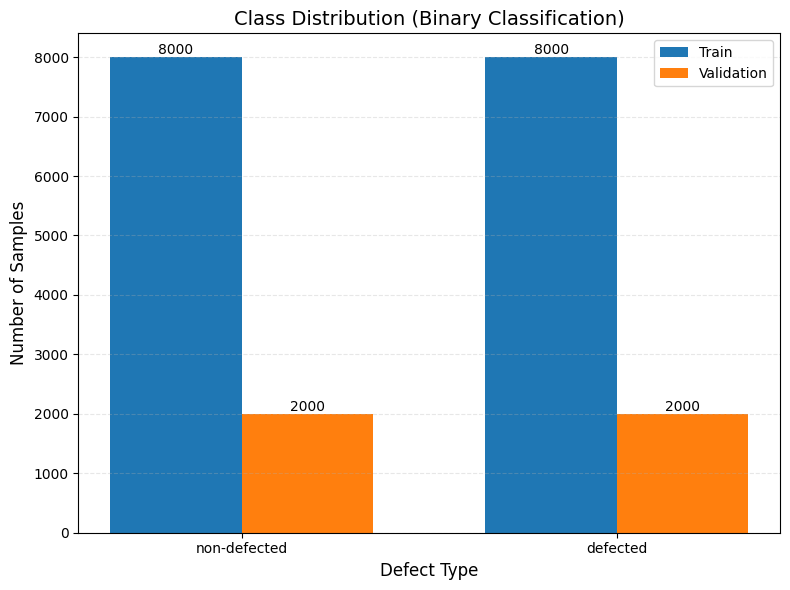

In [3]:
def plot_binary_class_distribution(y_train, y_test, class_names=['non-defected', 'defected']):
    train_counts = np.bincount(y_train, minlength=2)
    test_counts = np.bincount(y_test, minlength=2)

    bar_width = 0.35
    index = np.arange(2)

    plt.figure(figsize=(8, 6))
    bars_train = plt.bar(index - bar_width/2, train_counts, bar_width, label='Train', color='#1f77b4')
    bars_test = plt.bar(index + bar_width/2, test_counts, bar_width, label='Validation', color='#ff7f0e')

    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}', ha='center', va='bottom', fontsize=10)

    add_labels(bars_train)
    add_labels(bars_test)

    plt.title('Class Distribution (Binary Classification)', fontsize=14)
    plt.xlabel('Defect Type', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(index, class_names)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    image_paths, labels = prepare_datasets(DATASET_DIR)
    X_train, X_test, y_train, y_test = train_test_split(image_paths, labels, test_size=0.2, stratify=labels, random_state=SEED)

    plot_binary_class_distribution(y_train, y_test)


Sample predictions comparison:
Predicted labels: [1 0 0 1 0 0 1 0 1 1]
True labels:      [1 0 0 1 0 0 1 0 1 1]


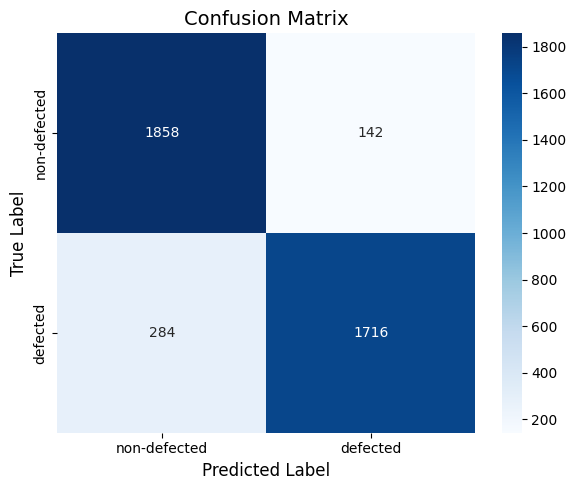

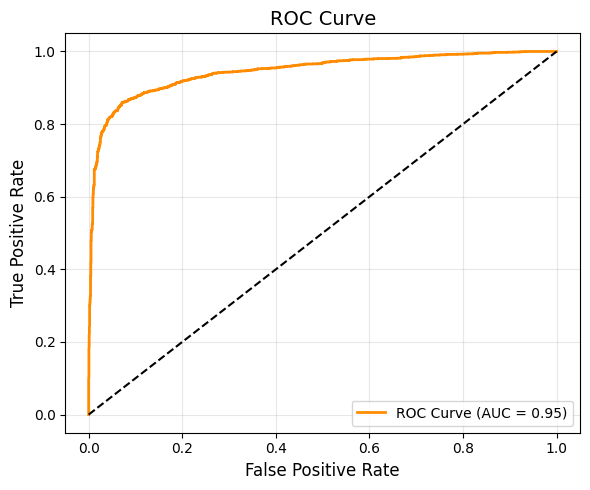

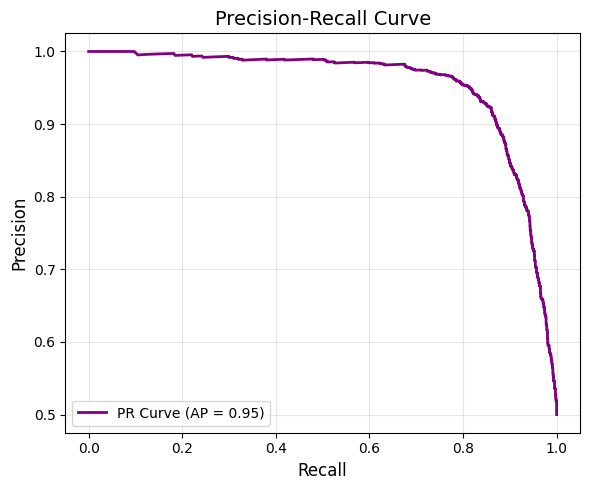


Key Metrics:
Accuracy: 0.8935
Precision: 0.9236
Recall: 0.8580
F1 Score: 0.8896
Average Precision (AP): 0.9537

Classification Report:
              precision    recall  f1-score   support

non-defected     0.8674    0.9290    0.8972      2000
    defected     0.9236    0.8580    0.8896      2000

    accuracy                         0.8935      4000
   macro avg     0.8955    0.8935    0.8934      4000
weighted avg     0.8955    0.8935    0.8934      4000



In [4]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)
import seaborn as sns

class_names = ['non-defected', 'defected']

y_pred_probs = model.predict(test_dataset).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

y_true = np.concatenate([y.numpy() for _, y in test_dataset], axis=0)

print("\nSample predictions comparison:")
print("Predicted labels:", y_pred[:10])
print("True labels:     ", y_true[:10])

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)
ap = average_precision_score(y_true, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='purple', lw=2, label=f"PR Curve (AP = {ap:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve", fontsize=14)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Metrics:")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
print(f"Average Precision (AP): {ap:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))



========== Start Pretrained Model Comparison ==========

Training ResNet50...
Epoch 1/50
500/500 [==============================] - 27s 49ms/step - loss: 0.7214 - accuracy: 0.5053 - val_loss: 0.6914 - val_accuracy: 0.5000
Epoch 2/50
500/500 [==============================] - 24s 49ms/step - loss: 0.6991 - accuracy: 0.5069 - val_loss: 0.6904 - val_accuracy: 0.5000
Epoch 3/50
500/500 [==============================] - 25s 49ms/step - loss: 0.6932 - accuracy: 0.5167 - val_loss: 0.6893 - val_accuracy: 0.5167
Epoch 4/50
500/500 [==============================] - 25s 49ms/step - loss: 0.6909 - accuracy: 0.5257 - val_loss: 0.6895 - val_accuracy: 0.5000
Epoch 5/50
500/500 [==============================] - 25s 50ms/step - loss: 0.6906 - accuracy: 0.5270 - val_loss: 0.6892 - val_accuracy: 0.5000
Epoch 6/50
500/500 [==============================] - 25s 50ms/step - loss: 0.6895 - accuracy: 0.5374 - val_loss: 0.6882 - val_accuracy: 0.5475
Epoch 7/50
500/500 [==============================] - 25s

E:\Anaconda\envs\TF2\lib\site-packages\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '



Classification Report for ResNet50:
              precision    recall  f1-score   support

non-defected       0.63      0.65      0.64      2000
    defected       0.64      0.62      0.63      2000

    accuracy                           0.64      4000
   macro avg       0.64      0.64      0.63      4000
weighted avg       0.64      0.64      0.63      4000


Training MobileNetV2...
Epoch 1/50
500/500 [==============================] - 14s 24ms/step - loss: 0.5389 - accuracy: 0.7226 - val_loss: 0.4662 - val_accuracy: 0.7747
Epoch 2/50
500/500 [==============================] - 12s 23ms/step - loss: 0.4635 - accuracy: 0.7771 - val_loss: 0.4356 - val_accuracy: 0.7937
Epoch 3/50
500/500 [==============================] - 12s 23ms/step - loss: 0.4430 - accuracy: 0.7906 - val_loss: 0.4230 - val_accuracy: 0.8018
Epoch 4/50
500/500 [==============================] - 12s 23ms/step - loss: 0.4232 - accuracy: 0.8012 - val_loss: 0.4111 - val_accuracy: 0.8092
Epoch 5/50
500/500 [===============

E:\Anaconda\envs\TF2\lib\site-packages\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '



Classification Report for MobileNetV2:
              precision    recall  f1-score   support

non-defected       0.84      0.94      0.89      2000
    defected       0.93      0.82      0.87      2000

    accuracy                           0.88      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.88      0.88      0.88      4000


Training DenseNet121...
Epoch 1/50
500/500 [==============================] - 31s 53ms/step - loss: 0.5343 - accuracy: 0.7277 - val_loss: 0.4609 - val_accuracy: 0.7770
Epoch 2/50
500/500 [==============================] - 26s 51ms/step - loss: 0.4585 - accuracy: 0.7831 - val_loss: 0.4280 - val_accuracy: 0.8012
Epoch 3/50
500/500 [==============================] - 26s 52ms/step - loss: 0.4295 - accuracy: 0.8036 - val_loss: 0.4079 - val_accuracy: 0.8138
Epoch 4/50
500/500 [==============================] - 26s 52ms/step - loss: 0.4150 - accuracy: 0.8112 - val_loss: 0.3931 - val_accuracy: 0.8225
Epoch 5/50
500/500 [============

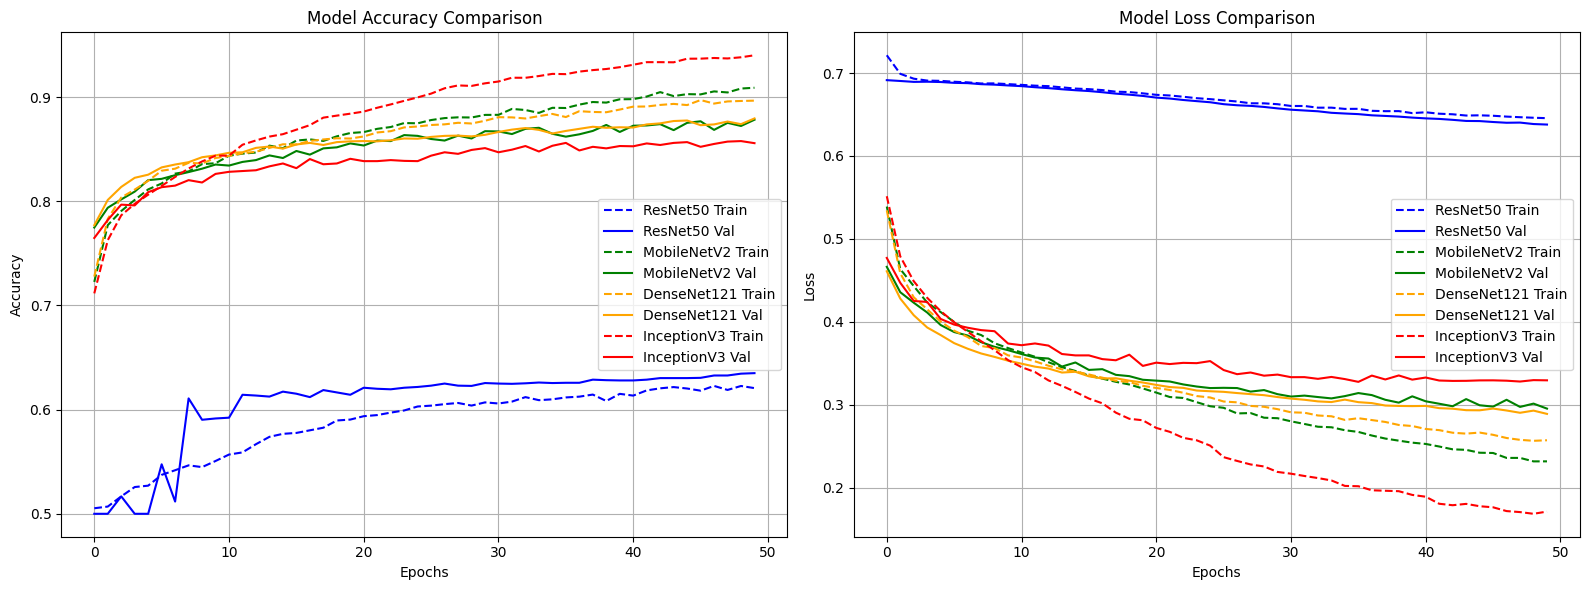

✅ All pretrained models evaluated.


In [5]:
from tensorflow.keras.applications import ResNet50, MobileNetV2, DenseNet121, InceptionV3

def build_pretrained_model(base_model, name="pretrained"):
    base_model.trainable = False
    inputs = layers.Input(shape=(TARGET_HEIGHT, TARGET_WIDTH, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs, name=name)
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

def plot_model_histories(histories):
    plt.figure(figsize=(16, 6))
    
    model_colors = {
        'ResNet50': 'blue',
        'MobileNetV2': 'green',
        'DenseNet121': 'orange',
        'InceptionV3': 'red'
    }

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        color = model_colors.get(name, None)
        plt.plot(history.history['accuracy'], linestyle='dashed', color=color, label=f'{name} Train')
        plt.plot(history.history['val_accuracy'], color=color, label=f'{name} Val')
    plt.title('Model Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        color = model_colors.get(name, None)
        plt.plot(history.history['loss'], linestyle='dashed', color=color, label=f'{name} Train')
        plt.plot(history.history['val_loss'], color=color, label=f'{name} Val')
    plt.title('Model Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def train_and_evaluate_pretrained_models():
    print("\n========== Start Pretrained Model Comparison ==========")

    resnet_model = build_pretrained_model(
        ResNet50(weights='imagenet', include_top=False, input_shape=(TARGET_HEIGHT, TARGET_WIDTH, 3)), name="ResNet50"
    )
    mobilenet_model = build_pretrained_model(
        MobileNetV2(weights='imagenet', include_top=False, input_shape=(TARGET_HEIGHT, TARGET_WIDTH, 3)), name="MobileNetV2"
    )
    densenet_model = build_pretrained_model(
        DenseNet121(weights='imagenet', include_top=False, input_shape=(TARGET_HEIGHT, TARGET_WIDTH, 3)), name="DenseNet121"
    )
    inception_model = build_pretrained_model(
        InceptionV3(weights='imagenet', include_top=False, input_shape=(TARGET_HEIGHT, TARGET_WIDTH, 3)), name="InceptionV3"
    )

    model_list = [resnet_model, mobilenet_model, densenet_model, inception_model]
    histories = {}

    for model in model_list:
        print(f"\nTraining {model.name}...")
        history = model.fit(
            train_dataset,
            validation_data=test_dataset,
            epochs=EPOCHS,
            class_weight=class_weights,
            callbacks=callbacks
        )
        histories[model.name] = history
        model.save(f"{model.name}_binary_model.h5")

        y_pred = (model.predict(test_dataset) > 0.5).astype("int32")
        print(f"\nClassification Report for {model.name}:")
        print(classification_report(y_test, y_pred, target_names=['non-defected', 'defected']))

    plot_model_histories(histories)
    print("✅ All pretrained models evaluated.")

train_and_evaluate_pretrained_models()


In [6]:
from numba import cuda

cuda.select_device(0)
cuda.close()